# Lab 3: Edge and line detection

In [ ]:
! pip install ipywidgets

In [2]:
import cv2
import numpy as np
import os
import math
from matplotlib import pyplot as plt
import ipywidgets as widgets

dataDir = 'images'

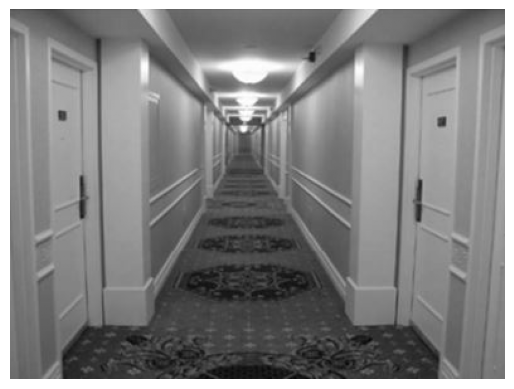

In [3]:
# Open image
img = cv2.imread(os.path.join(dataDir, 'corridor_01.jpg')) # Change this, according to your image's path

# Convert to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img, cmap="gray", vmin=0, vmax=255)
_ = plt.axis("off")

### 1. Sobel Filter

Detecting edges using the [Sobel Filter](https://docs.opencv.org/master/d4/d86/group__imgproc__filter.html#gacea54f142e81b6758cb6f375ce782c8d)

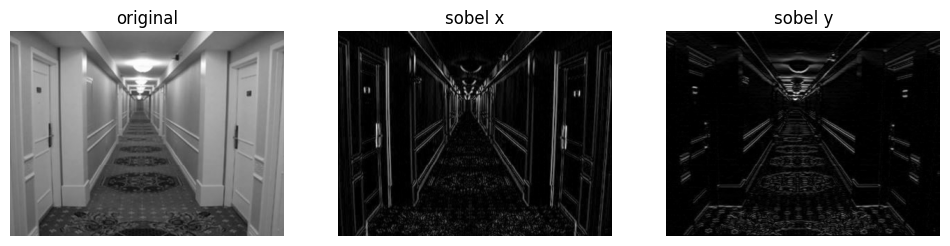

In [4]:
# Calculate the first derivatives of the image in x and y
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Normalize the result 
sobel_x = (np.abs(sobel_x) / np.abs(sobel_x).max()) * 255.
sobel_y = (np.abs(sobel_y) / np.abs(sobel_y).max()) * 255.

# Show the images
f, axarr = plt.subplots(1, 3, figsize=(12, 4))

axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("original")
axarr[0].axis("off")

axarr[1].imshow(sobel_x, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("sobel x")
axarr[1].axis("off")

axarr[2].imshow(sobel_y, cmap="gray", vmin=0, vmax=255)
axarr[2].set_title("sobel y")
_ = axarr[2].axis("off")

Exercise 1.1: Calculate the magnitude of the gradient by combining the previously calculated partial derivatives (sobel_x and sobel_y) and show the resulting image.

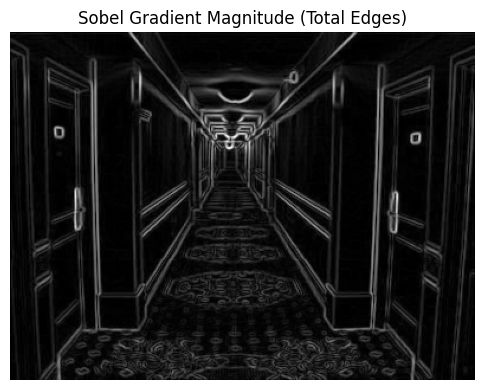

In [5]:
sobel_magnitude = np.sqrt(sobel_x ** 2 + sobel_y ** 2)

sobel_magnitude = (sobel_magnitude / sobel_magnitude.max()) * 255.

plt.figure(figsize=(6, 6))
plt.imshow(sobel_magnitude, cmap="gray", vmin=0, vmax=255)
plt.title("Sobel Gradient Magnitude (Total Edges)")
plt.axis("off")

plt.show()

Exercise 1.2: Threshold the gradient image using an interactive slider (e.g., [opencv trackbar](https://docs.opencv.org/4.x/da/d6a/tutorial_trackbar.html) or [pywidgets interact](https://ipywidgets.readthedocs.io/en/8.1.2/examples/Using%20Interact.html)).

In [ ]:
def interactive_threshold(threshold_value):
    
    # If the pixel value is greater than the threshold, set it to 255 (white)
    # Otherwise, set it to 0 (black)
    binary_edges = np.where(sobel_magnitude > threshold_value, 255, 0)
    
    # 2. Display the resulting binary image
    plt.figure(figsize=(8, 8))
    plt.imshow(binary_edges, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Binary Edges (Threshold = {threshold_value})")
    plt.axis("off")
    plt.show()

# min=0, max=255 (normalized range), starting at a default value of 50
widgets.interact(interactive_threshold, threshold_value=widgets.IntSlider(min=0, max=255, step=1, value=50))

interactive(children=(IntSlider(value=50, description='threshold_value', max=255), Output()), _dom_classes=('w…

<function __main__.interactive_threshold(threshold_value)>

Exercise 1.3: Test the effect of applying Gaussian blur filters of different sizes before applying the Sobel filter.

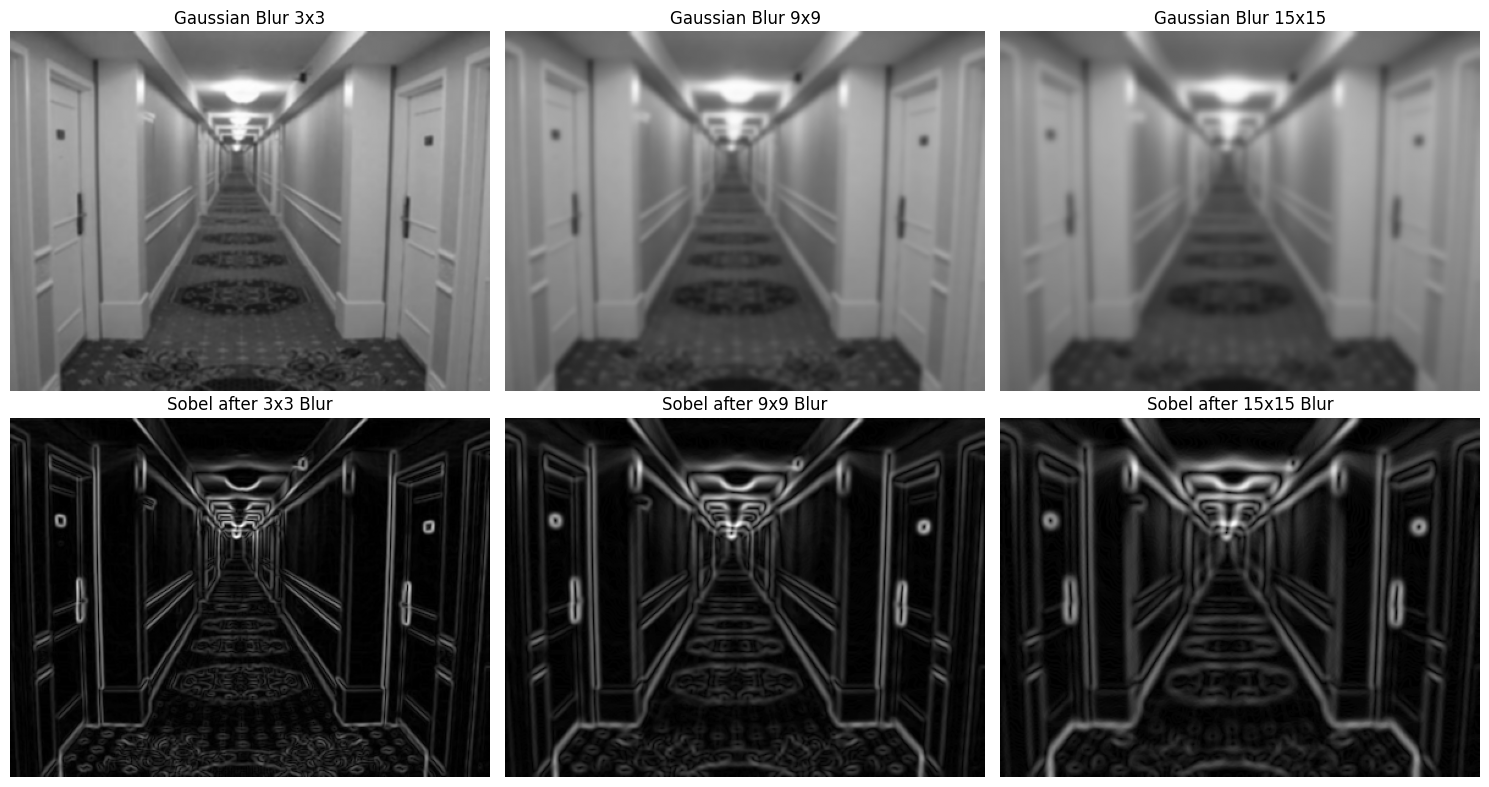

In [7]:
kernel_sizes = [(3, 3), (9, 9), (15, 15)]

# Create a plot with 2 rows (Blurred Image and Sobel Result) and 3 columns
f, axarr = plt.subplots(2, len(kernel_sizes), figsize=(15, 8))

for i, k in enumerate(kernel_sizes):
    
    # Apply Gaussian Blur with the current kernel size
    # The '0' tells OpenCV to automatically calculate the standard deviation
    blurred_img = cv2.GaussianBlur(img, k, 0)
    
    sobel_x = cv2.Sobel(blurred_img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(blurred_img, cv2.CV_64F, 0, 1, ksize=3)
    
    magnitude = np.hypot(sobel_x, sobel_y)
    magnitude = (magnitude / magnitude.max()) * 255.0
    
    axarr[0, i].imshow(blurred_img, cmap="gray", vmin=0, vmax=255)
    axarr[0, i].set_title(f"Gaussian Blur {k[0]}x{k[1]}")
    axarr[0, i].axis("off")
    
    axarr[1, i].imshow(magnitude, cmap="gray", vmin=0, vmax=255)
    axarr[1, i].set_title(f"Sobel after {k[0]}x{k[1]} Blur")
    axarr[1, i].axis("off")

plt.tight_layout()
plt.show()

Exercise 1.4: Experiment with different kernel sizes in the sobel filter

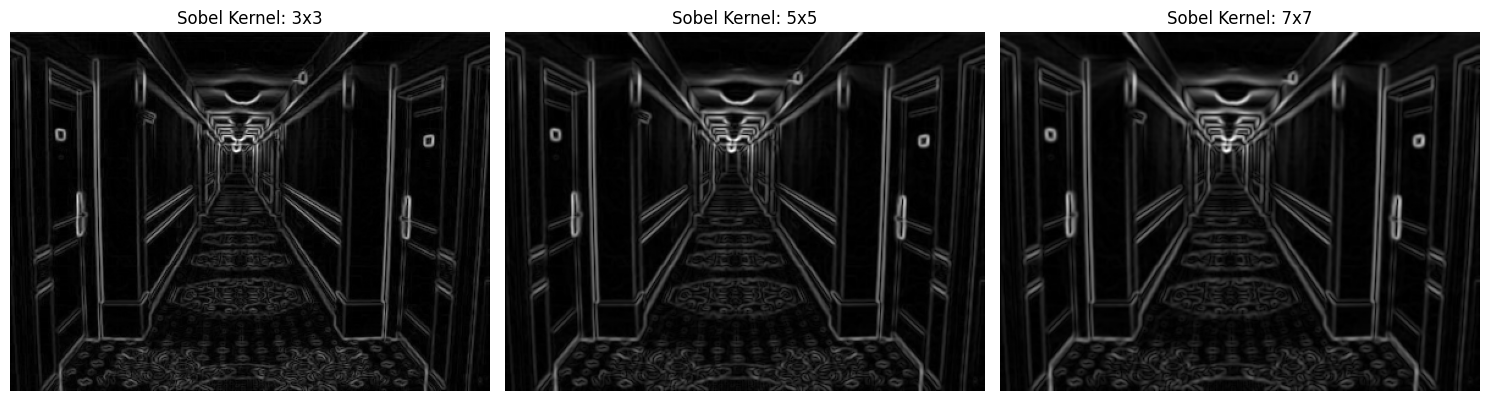

In [8]:
sobel_ksizes = [3, 5, 7]

f, axarr = plt.subplots(1, len(sobel_ksizes), figsize=(15, 5))

for i, k in enumerate(sobel_ksizes):
    
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=k)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=k)
    
    magnitude = np.hypot(sobel_x, sobel_y)
    magnitude = (magnitude / magnitude.max()) * 255.0
    
    axarr[i].imshow(magnitude, cmap="gray", vmin=0, vmax=255)
    axarr[i].set_title(f"Sobel Kernel: {k}x{k}")
    axarr[i].axis("off")

plt.tight_layout()
plt.show()

### 2. Laplacian of Gaussian (LoG) and Difference of Gaussians (DoG)

Edge detection using the Laplacian filter

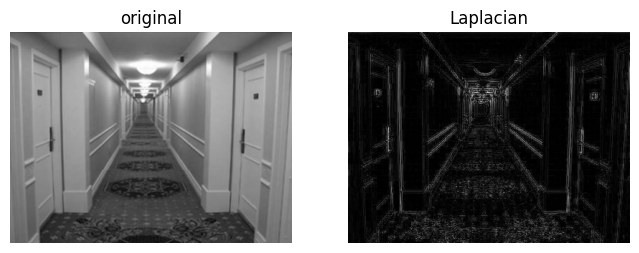

In [9]:
# Open image
img = cv2.imread(os.path.join(dataDir, 'corridor_01.jpg')) # Change this, according to your image's path

# Convert to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Laplacian
laplacian = cv2.Laplacian(img, cv2.CV_64F, ksize=3)

# Normalize result
laplacian = (np.abs(laplacian) / np.abs(laplacian).max()) * 255.

## Show the image
f, axarr = plt.subplots(1, 2, figsize=(8, 4))

axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("original")
axarr[0].axis("off")

axarr[1].imshow(laplacian, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("Laplacian")
_ = axarr[1].axis("off")

Exercise 2.1: Calculate the Laplacian of Gaussian by applying a Gaussian filter before applying the Laplacian filter

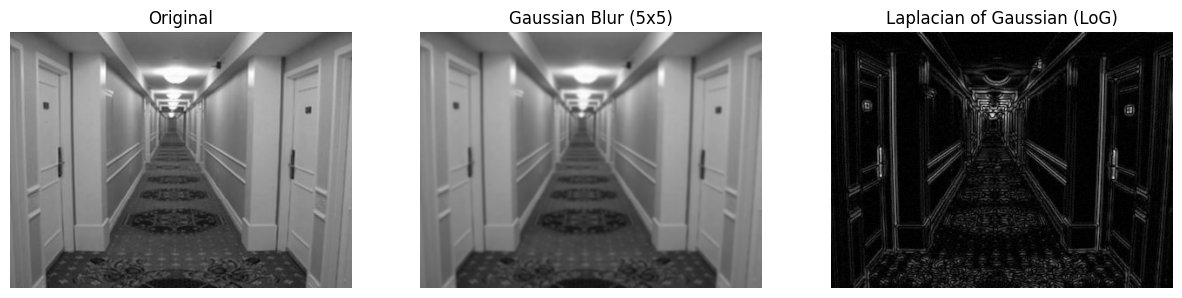

In [10]:
img_blurred = cv2.GaussianBlur(img, (5, 5), 0)

log_img = cv2.Laplacian(img_blurred, cv2.CV_64F, ksize=3)

log_img_normalized = (np.abs(log_img) / np.abs(log_img).max()) * 255.0

f, axarr = plt.subplots(1, 3, figsize=(15, 5))

axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("Original")
axarr[0].axis("off")

axarr[1].imshow(img_blurred, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("Gaussian Blur (5x5)")
axarr[1].axis("off")

axarr[2].imshow(log_img_normalized, cmap="gray", vmin=0, vmax=255)
axarr[2].set_title("Laplacian of Gaussian (LoG)")
axarr[2].axis("off")

plt.show()

Exercise 2.2: Implement edge detection through Difference of Gaussians

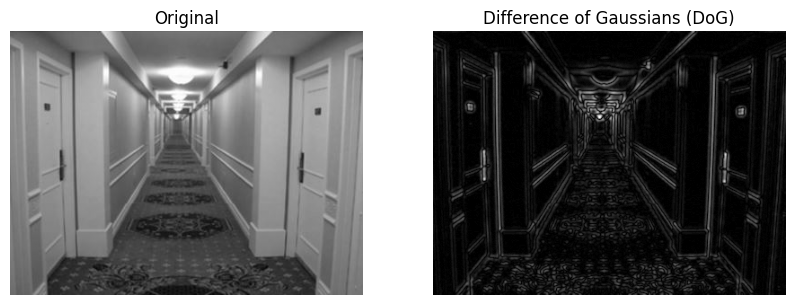

In [11]:
# Apply two Gaussian blurs with different kernel sizes
# The first blur is slight, the second is stronger
blur1 = cv2.GaussianBlur(img, (5, 5), 1.0)
blur2 = cv2.GaussianBlur(img, (9, 9), 2.0)

# Convert to float to avoid negative number wrap-around issues (!VERY IMPORTANT!)
blur1_float = np.float64(blur1)
blur2_float = np.float64(blur2)

dog_img = blur1_float - blur2_float

dog_normalized = (np.abs(dog_img) / np.abs(dog_img).max()) * 255.0

f, axarr = plt.subplots(1, 2, figsize=(10, 5))

axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("Original")
axarr[0].axis("off")

axarr[1].imshow(dog_normalized, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("Difference of Gaussians (DoG)")
axarr[1].axis("off")

plt.show()

### 3. Canny Edge Filter

Detect edges using the [Canny Filter](https://docs.opencv.org/master/dd/d1a/group__imgproc__feature.html#ga04723e007ed888ddf11d9ba04e2232de)

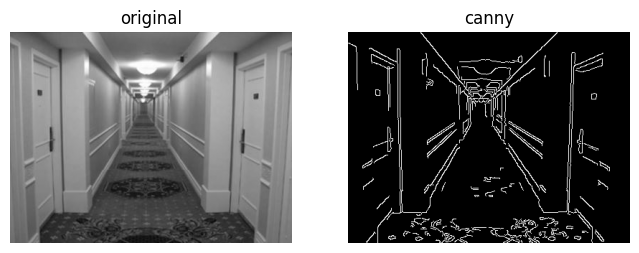

In [12]:
# Apply a Canny Filter
img_canny = cv2.Canny(img, 100, 200)

# Show image
f, axarr = plt.subplots(1, 2, figsize=(8, 4))

axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("original")
axarr[0].axis("off")

axarr[1].imshow(img_canny, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("canny")
_ = axarr[1].axis("off")

Exercise 3.1: Implement two track bars to alter the low and high threshold values of the Canny filter

In [13]:
def interactive_canny(low_thresh, high_thresh):
    
    # cv2.Canny automatically handles the Gaussian blur, Sobel, and Hysteresis inside
    img_canny = cv2.Canny(img, low_thresh, high_thresh)
    
    f, axarr = plt.subplots(1, 2, figsize=(12, 6))
    
    axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axarr[0].set_title("Original")
    axarr[0].axis("off")
    
    axarr[1].imshow(img_canny, cmap="gray", vmin=0, vmax=255)
    axarr[1].set_title(f"Canny (Low: {low_thresh}, High: {high_thresh})")
    axarr[1].axis("off")
    
    plt.show()

widgets.interact(
    interactive_canny, 
    low_thresh=widgets.IntSlider(min=0, max=255, step=1, value=50, description='Low Thresh'),
    high_thresh=widgets.IntSlider(min=0, max=255, step=1, value=150, description='High Thresh')
)

interactive(children=(IntSlider(value=50, description='Low Thresh', max=255), IntSlider(value=150, description…

<function __main__.interactive_canny(low_thresh, high_thresh)>

Exercise 3.2: Compare the results of applying the following two filters to the same image:
 - Sobel filter, with threshold t, after smoothing the image with a Gaussian blur filter with size s;
 - Canny filter, with "low threshold" = "high threshold" = t and "aperture" = s, using the same t and s values. Try also with a "low threshold" different from the "high threshold".

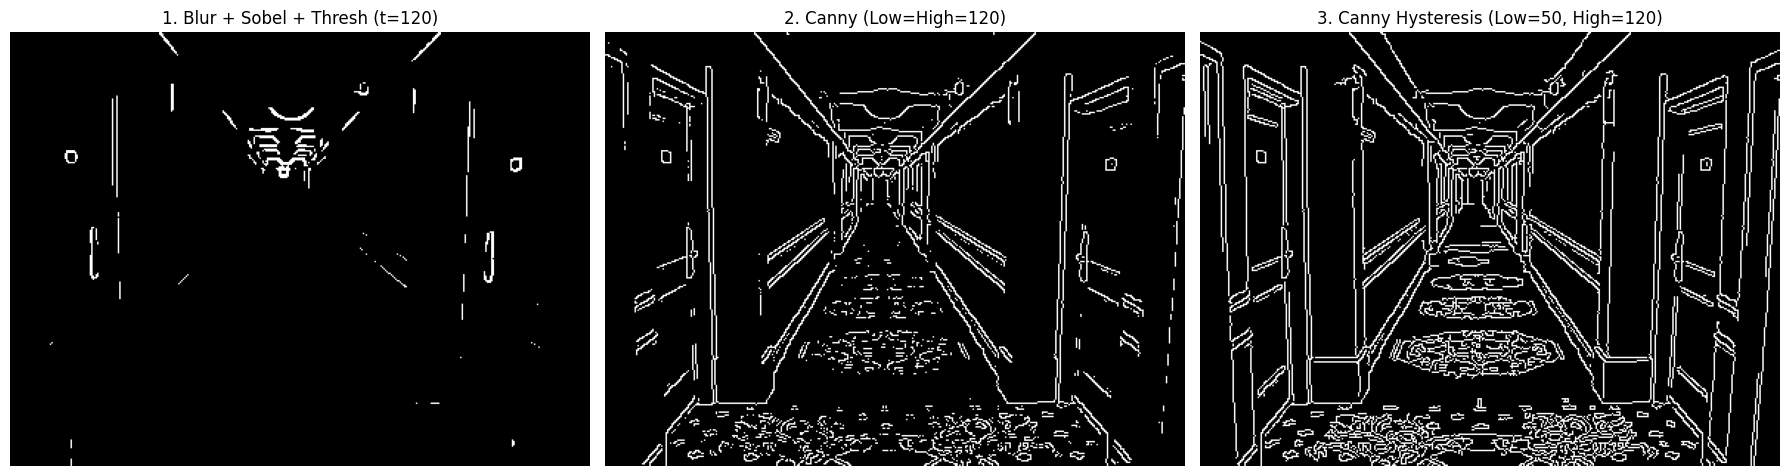

In [14]:
s = 3    # Kernel size / Aperture size (must be odd)
t = 120  # Threshold value
t_low = 50 # Lower threshold for the final Canny test

blurred = cv2.GaussianBlur(img, (s, s), 0)

sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=s)
sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=s)

magnitude = np.hypot(sobel_x, sobel_y)
magnitude = (magnitude / magnitude.max()) * 255.0

_, sobel_thresh = cv2.threshold(magnitude, t, 255, cv2.THRESH_BINARY)

canny_equal = cv2.Canny(img, t, t, apertureSize=s)

canny_hysteresis = cv2.Canny(img, t_low, t, apertureSize=s)

f, axarr = plt.subplots(1, 3, figsize=(18, 6))

axarr[0].imshow(sobel_thresh, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title(f"1. Blur + Sobel + Thresh (t={t})")
axarr[0].axis("off")

axarr[1].imshow(canny_equal, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title(f"2. Canny (Low=High={t})")
axarr[1].axis("off")

axarr[2].imshow(canny_hysteresis, cmap="gray", vmin=0, vmax=255)
axarr[2].set_title(f"3. Canny Hysteresis (Low={t_low}, High={t})")
axarr[2].axis("off")

plt.tight_layout()
plt.show()

### Extra: Hough Line Transform

Example of [Standard Hough Lines Transform](https://docs.opencv.org/3.4/dd/d1a/group__imgproc__feature.html#ga46b4e588934f6c8dfd509cc6e0e4545a)

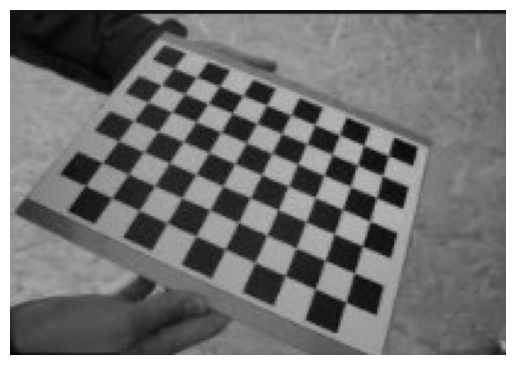

In [23]:
# Opening an image
img2 = cv2.imread(os.path.join(dataDir, 'chessboard_02.jpg'))

# Convert to grayscale
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Display image
plt.imshow(img2, cmap="gray", vmin=0, vmax=255)
_ = plt.axis("off")

Step 1: Detect the edges of the input image using a Canny Filter

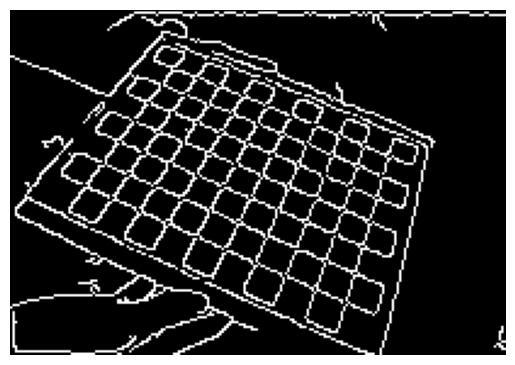

In [28]:
# Apply Canny filter
img2_canny = cv2.Canny(img2, 50, 200)

# Create BGR copy of image
img2_copy = cv2.cvtColor(img2_canny, cv2.COLOR_GRAY2BGR)

# Display image
plt.imshow(img2_canny, cmap="gray", vmin=0, vmax=255)
_ = plt.axis("off")

Step 2: Apply Hough Transform

In [29]:
num_votes = 60

lines = cv2.HoughLines(img2_canny, 1, np.pi / 180, num_votes, None, 0, 0)

Step 3: Draw the lines

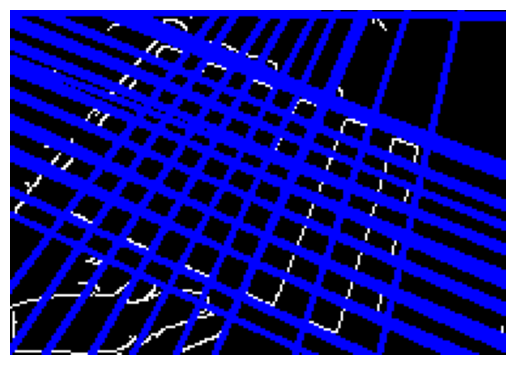

In [30]:
if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        # Draw the line
        cv2.line(img2_copy, pt1, pt2, (255, 0, 0), 2)

## Show the image
plt.imshow(cv2.cvtColor(img2_copy, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")
